In [1]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.models.binary_classification import BinaryClassificationJob
from neuralnet.plotting import plot_metric_comparison

2026-06-08 13:45:44.618836: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 13:45:44.693122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 13:45:46.211217: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 13:45:46.212594: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not 

In [2]:
jobs_dir = Path.home() / "data" / "neuralnet_jobs"
jobs = {
    'mlp':{
        "model_label": "MLP (Ref)",
        "path": jobs_dir / 'mlp',
        "color": "C0",
        "marker": "o",
    },
    'basic_entangler': {
        "model_label": "Entrelaçamento Básico",
        "path": jobs_dir / 'basic_entangler',
        "color": "C1",
        "marker": "s",
    },
    'hardware_efficient': {
        "model_label": "Rotação completa",
        "path": jobs_dir / 'hardware_efficient',
        "color": "C3",
        "marker": "D",
    },
    'strongly_entangling': {
        "model_label": "Entrelaçamento Forte",
        "path": jobs_dir / 'strongly_entangling',
        "color": "C2",
        "marker": "^",
    },
}

In [3]:
for job in jobs.values():
    print(f"Loading job: {job['model_label']}")
    job_instance = BinaryClassificationJob.load(job['path'])
    job['job'] = job_instance

/home/lucasbanunes/miniconda3/envs/neuralnet/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loading job: MLP (Ref)
Loading job: Entrelaçamento Básico
Loading job: Rotação completa
Loading job: Entrelaçamento Forte


In [4]:
metric_prefixes = (
    'train', 'val', 'test'
)
continue_if_ends = (
    'loss',
    'auc'
)
for job in jobs.values():
    print(f"Processing job: {job['model_label']}")
    aggregation_expressions = list()
    df = job['job'].results.clone()
    df = df.with_columns(
        pl.col('val.sp_index').list.arg_max().alias('max_sp_idx')
    )
    max_sp_idx = pl.col('max_sp_idx')
    for col in df.columns:
        if not col.startswith(metric_prefixes) or col.endswith(continue_if_ends):
            continue
        alias = f'{col}_max_sp'
        max_sp_metric = pl.col(col).list.get(max_sp_idx).alias(alias)
        # df = df.filter(pl.col('init') != 1).with_columns(max_sp_metric)
        df = df.with_columns(max_sp_metric)
        aggregation_expressions.append(pl.col(alias).mean().alias(f'{alias}.mean'))
        aggregation_expressions.append(pl.col(alias).std().alias(f'{alias}.std'))
        aggregation_expressions.append(pl.col(alias).min().alias(f'{alias}.min'))
        aggregation_expressions.append(pl.col(alias).max().alias(f'{alias}.max'))
    
    job['results'] = df
    job['results_by_fold'] = df.group_by('fold').agg(*aggregation_expressions)

Processing job: MLP (Ref)
Processing job: Entrelaçamento Básico
Processing job: Rotação completa
Processing job: Entrelaçamento Forte


In [5]:
jobs['basic_entangler']['results'].schema

Schema([('fold', Int64),
        ('init', Int64),
        ('fit.accuracy', List(Float64)),
        ('fit.loss', List(Float64)),
        ('fit.val_accuracy', List(Float64)),
        ('fit.val_loss', List(Float64)),
        ('fit.max_sp_val', List(Float64)),
        ('fit.max_sp_fa_val', List(Float64)),
        ('fit.max_sp_pd_val', List(Float64)),
        ('fit.max_sp_best_epoch_val', List(Int64)),
        ('train.loss', Float64),
        ('train.tn', List(Float64)),
        ('train.tp', List(Float64)),
        ('train.fn', List(Float64)),
        ('train.fp', List(Float64)),
        ('train.thresholds', List(Float64)),
        ('train.accuracy', List(Float64)),
        ('train.tpr', List(Float64)),
        ('train.fpr', List(Float64)),
        ('train.sp_index', List(Float64)),
        ('train.auc', Float64),
        ('val.loss', Float64),
        ('val.tn', List(Float64)),
        ('val.tp', List(Float64)),
        ('val.fn', List(Float64)),
        ('val.fp', List(Float64)),
        

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27888/2534649089.py:23: SyntaxWarning: invalid escape sequence '\m'
  title=f'{metric_label} por Fold $\mu \pm 3 \sigma$'
/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:83: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  top_ax.errorbar(
/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:107: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  bottom_ax.errorbar(
/tmp/ipykernel_27888/2534649089.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


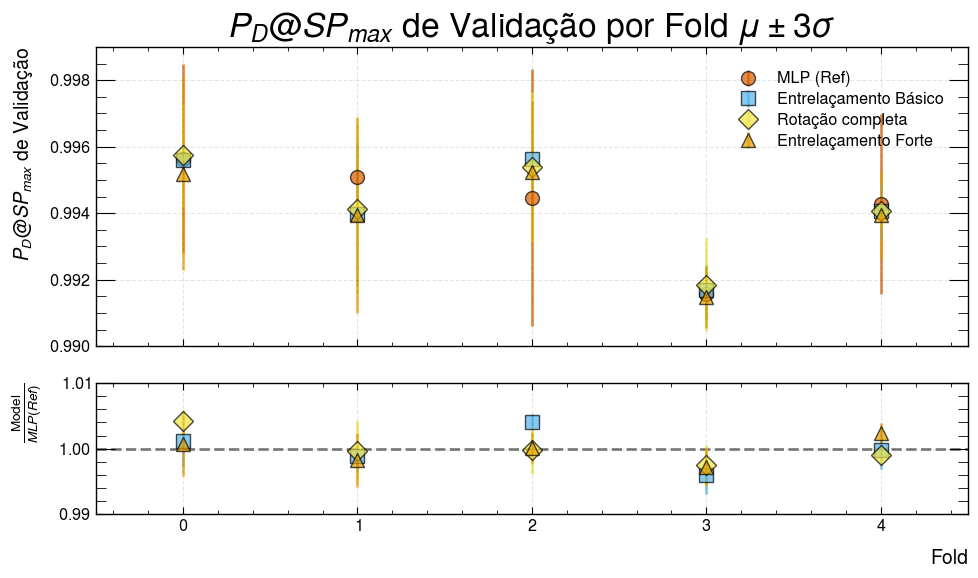

In [6]:
metric = 'val.tpr_max_sp'
metric_label=r'$P_D @ SP_{max}$ de Validação'
to_plot = {}
for job_name, job in jobs.items():
    df = job['results_by_fold']
    to_plot[job_name] = {
        'label': job['model_label'],
        'x': df['fold'],
        'y': df[f'{metric}.mean'],
        'yerr': 3*df[f'{metric}.std'],
        'color': job['color'],
        'marker': job['marker']
    }
fig, _, _ = plot_metric_comparison(
    metric_label=metric_label,
    ref_name='mlp',
    to_plot=to_plot,
    fig_kwargs={
        'figsize': (10, 6)
    },
    xlim=(-0.5, 4.5),
    xticks=range(5),
    title=f'{metric_label} por Fold $\mu \pm 3 \sigma$'
)
fig.show()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27888/3257283051.py:22: SyntaxWarning: invalid escape sequence '\m'
  title=f'{metric_label} de Validação por Fold $\mu \pm 3 \sigma$',
/tmp/ipykernel_27888/3257283051.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


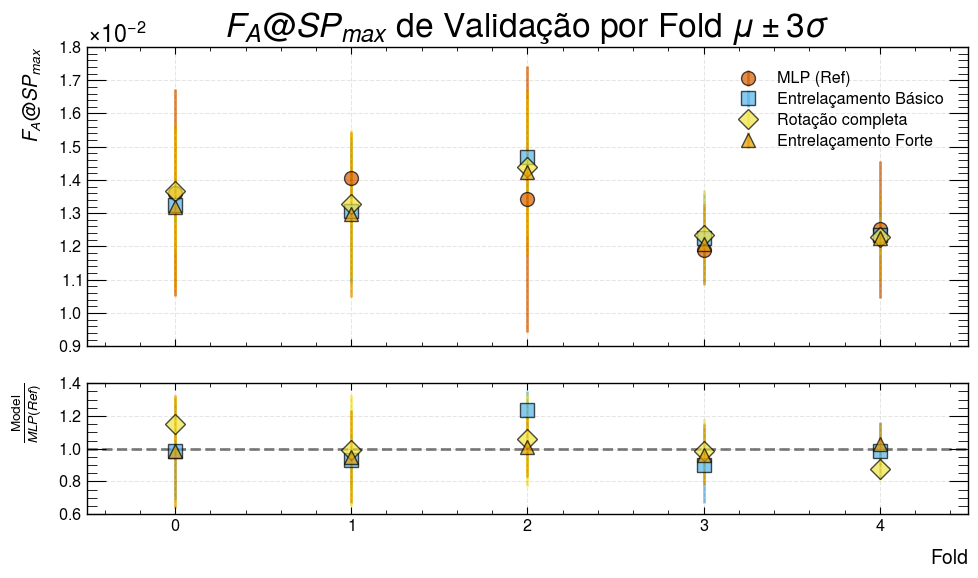

In [9]:
metric = 'val.fpr_max_sp'
metric_label=r'$F_A @ SP_{max}$'
to_plot = {}
for job_name, job in jobs.items():
    to_plot[job_name] = {
        'label': job['model_label'],
        'x': job['results_by_fold']['fold'],
        'y': job['results_by_fold'][f'{metric}.mean'],
        'yerr': 3*job['results_by_fold'][f'{metric}.std'],
        'color': job['color'],
        'marker': job['marker']
    }
fig, _, _ = plot_metric_comparison(
    metric_label=metric_label,
    ref_name='mlp',
    to_plot=to_plot,
    fig_kwargs={
        'figsize': (10, 6)
    },
    xlim=(-0.5, 4.5),
    xticks=range(5),
    title=f'{metric_label} de Validação por Fold $\mu \pm 3 \sigma$',
)
fig.show()

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_27888/4202129408.py:23: SyntaxWarning: invalid escape sequence '\m'
  title=f'{metric_label} de Validação por Fold $\mu \pm 3 \sigma$',
/tmp/ipykernel_27888/4202129408.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


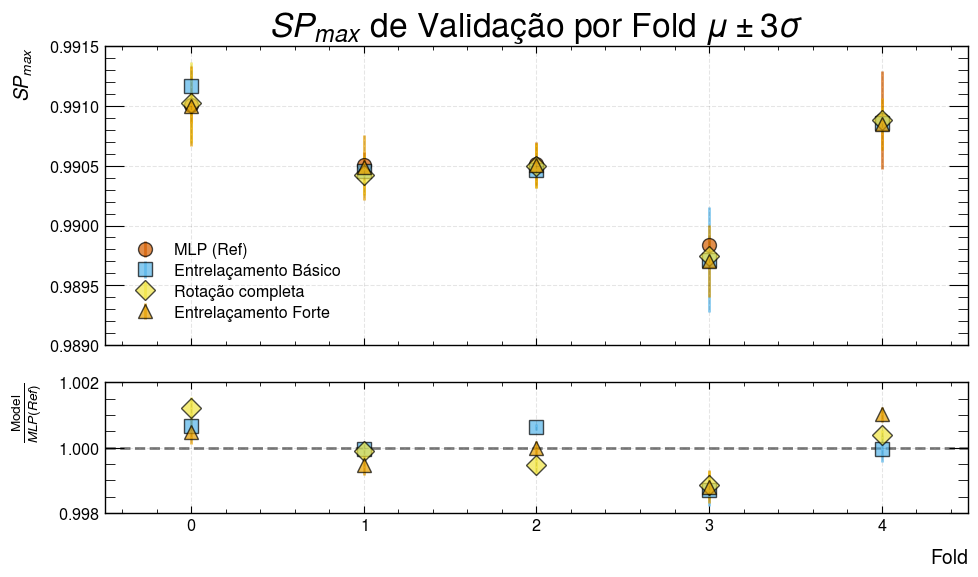

In [11]:
metric = 'val.sp_index_max_sp'
metric_label=r'$SP_{max}$'
to_plot = {}
for job_name, job in jobs.items():
    df = job['results_by_fold'].filter(pl.col(f'{metric}.mean') > 0.1)
    to_plot[job_name] = {
        'label': job['model_label'],
        'x': df['fold'],
        'y': df[f'{metric}.mean'],
        'yerr': 3*df[f'{metric}.std'],
        'color': job['color'],
        'marker': job['marker']
    }
fig, _, _ = plot_metric_comparison(
    metric_label=metric_label,
    ref_name='mlp',
    to_plot=to_plot,
    fig_kwargs={
        'figsize': (10, 6)
    },
    xlim=(-0.5, 4.5),
    xticks=range(5),
    title=f'{metric_label} de Validação por Fold $\mu \pm 3 \sigma$',
)
fig.show()

In [136]:
jobs['basic_entangler']['results'].sort('val.tpr_max_sp', descending=True).select('val.tpr_max_sp', 'fold', 'init')

val.tpr_max_sp,fold,init
f64,i64,i64
1.0,2,1
0.995963,2,0
0.995854,2,4
0.9958,0,0
0.995618,0,1
…,…,…
0.9935,1,4
0.992323,3,1
0.991726,3,2


Fold: 0, Values: [0.9953469038009644, 0.9957271218299866, 0.9957995414733887, 0.9955460429191589]
Fold: 1, Values: [0.9937717318534851, 0.9950391054153442, 0.9935001730918884, 0.9936087727546692]
Fold: 2, Values: [0.9953469038009644, 0.9953106641769409, 0.995853841304779, 0.9959625005722046]
Fold: 3, Values: [0.9920156598091125, 0.9913819432258606, 0.9917259812355042, 0.9916173219680786]
Fold: 4, Values: [0.9938623905181885, 0.9944779276847839, 0.993989109992981, 0.9939348101615906]


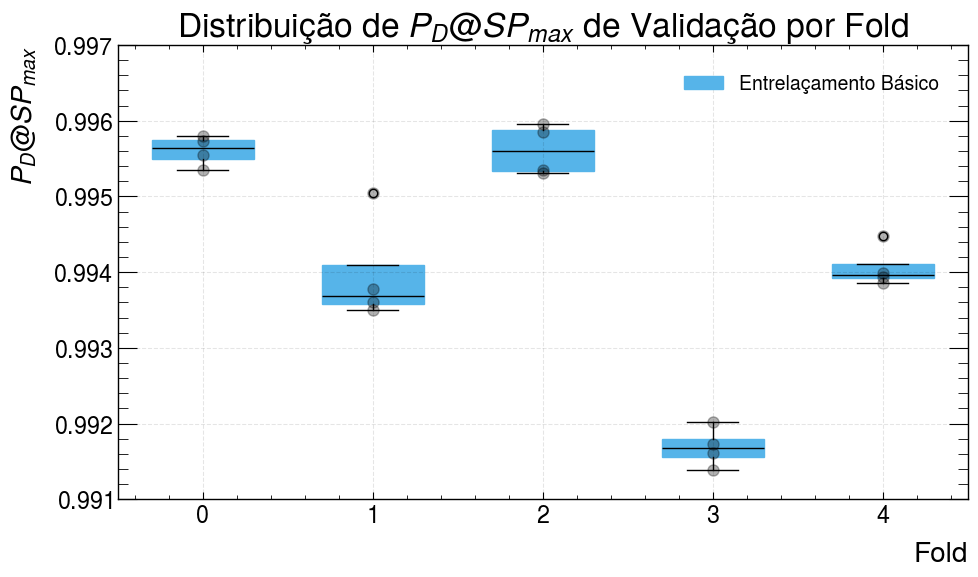

In [12]:
job_to_plot = jobs['basic_entangler']
metric_name = 'val.tpr_max_sp'
metric_label = r'$P_D @ SP_{max}$'
fig, ax = plt.subplots(figsize=(10, 6))
df_to_plot = job_to_plot['results'].group_by('fold').agg(pl.col(metric_name)).sort('fold')
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.boxplot(
    df_to_plot[metric_name].to_numpy(),
    tick_labels=df_to_plot['fold'].to_numpy(),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor=job_to_plot['color'], color=job_to_plot['color']),
    medianprops=dict(color='black'),
    label=job_to_plot['model_label']
)
scatter_df = df_to_plot.explode(pl.col(metric_name))
ax.scatter(
    x=scatter_df['fold'].to_numpy() + 1,
    y=scatter_df[metric_name].to_numpy(),
    color='k',
    edgecolor='black',
    zorder=3,
    alpha=0.3
)
ax.set_xlabel('Fold')
ax.set_ylabel(metric_label)
ax.set_title(f'Distribuição de {metric_label} de Validação por Fold')
ax.legend()
fig.tight_layout()
for row in df_to_plot.iter_rows():
    fold = row[0]
    values = row[1]
    print(f"Fold: {fold}, Values: {values}")

Fold: 0, Values: [0.013094775378704071, 0.013354077935218811, 0.013483729213476181, 0.013094775378704071]
Fold: 1, Values: [0.012835472822189331, 0.014131984673440456, 0.012576170265674591, 0.012705821543931961]
Fold: 2, Values: [0.014391287229955196, 0.014391287229955196, 0.014909892342984676, 0.015039543621242046]
Fold: 3, Values: [0.012577801011502743, 0.011799792759120464, 0.012707469053566456, 0.011929460801184177]
Fold: 4, Values: [0.012188796885311604, 0.012707469053566456, 0.012318464927375317, 0.012188796885311604]


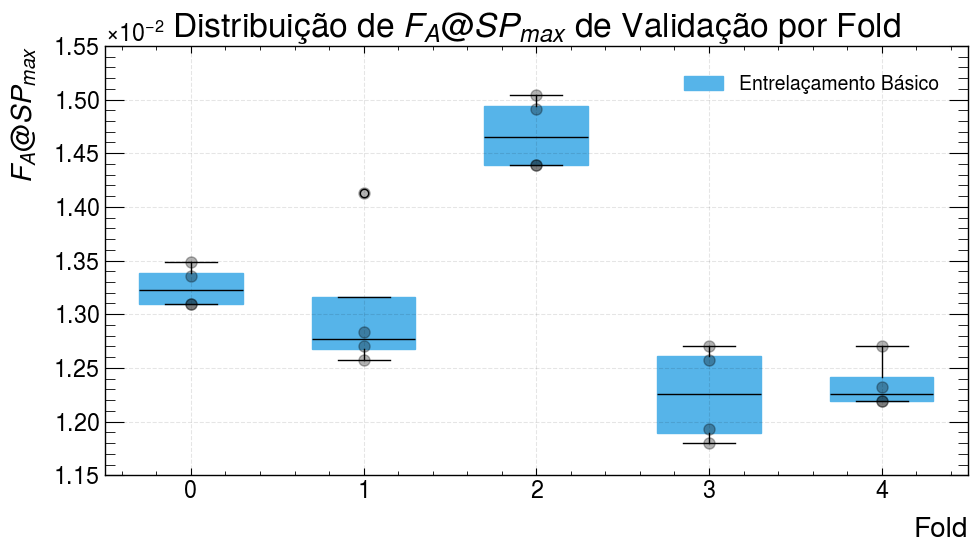

In [13]:
job_to_plot = jobs['basic_entangler']
metric_name = 'val.fpr_max_sp'
metric_label=r'$F_A @ SP_{max}$'
fig, ax = plt.subplots(figsize=(10, 6))
df_to_plot = job_to_plot['results'].group_by('fold').agg(pl.col(metric_name)).sort('fold')
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.boxplot(
    df_to_plot[metric_name].to_numpy(),
    tick_labels=df_to_plot['fold'].to_numpy(),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor=job_to_plot['color'], color=job_to_plot['color']),
    medianprops=dict(color='black'),
    label=job_to_plot['model_label']
)
scatter_df = df_to_plot.explode(pl.col(metric_name))
ax.scatter(
    x=scatter_df['fold'].to_numpy() + 1,
    y=scatter_df[metric_name].to_numpy(),
    color='k',
    edgecolor='black',
    zorder=3,
    alpha=0.3
)
ax.set_xlabel('Fold')
ax.set_ylabel(metric_label)
ax.set_title(f'Distribuição de {metric_label} de Validação por Fold')
ax.legend()
fig.tight_layout()
for row in df_to_plot.iter_rows():
    fold = row[0]
    values = row[1]
    print(f"Fold: {fold}, Values: {values}")

Fold: 0, Values: [0.991192102432251, 0.9911215305328369, 0.9911813139915466, 0.9911524653434753, 0.9912208914756775]
Fold: 1, Values: [0.9904653429985046, 0.9904482960700989, 0.990459680557251, 0.990424633026123, 0.9904489517211914]
Fold: 2, Values: [0.9904717803001404, 0.9904537796974182, 0.9904646277427673, 0.0, 0.990453839302063]
Fold: 3, Values: [0.9897176027297974, 0.9897904396057129, 0.9895080327987671, 0.9895467162132263, 0.9898431897163391]
Fold: 4, Values: [0.9908344745635986, 0.9907333850860596, 0.9908819794654846, 0.9908328056335449, 0.9908705949783325]


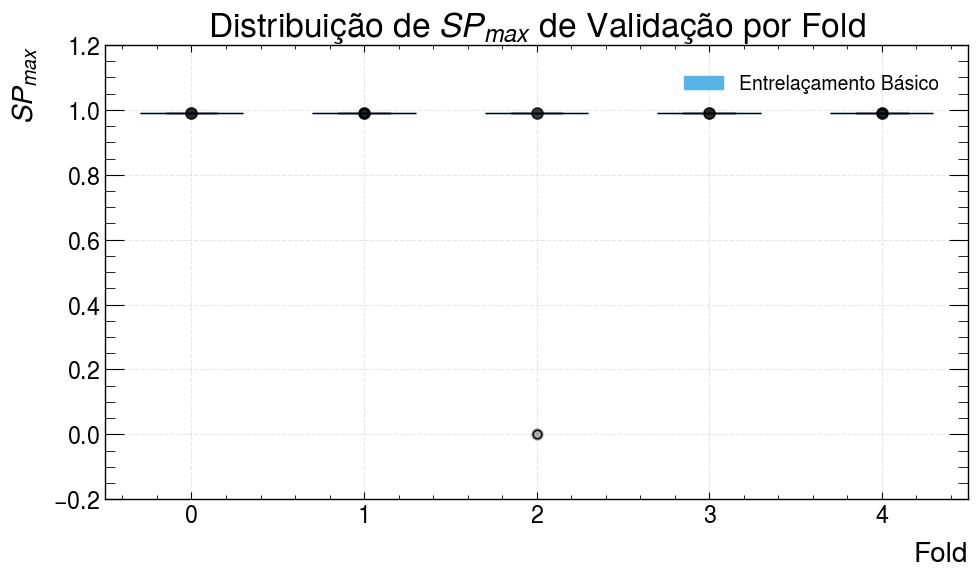

In [6]:
job_to_plot = jobs['basic_entangler']
metric_name = 'val.sp_index_max_sp'
metric_label=r'$SP_{max}$'
fig, ax = plt.subplots(figsize=(10, 6))
df_to_plot = job_to_plot['results'].group_by('fold').agg(pl.col(metric_name)).sort('fold')
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.boxplot(
    df_to_plot[metric_name].to_numpy(),
    tick_labels=df_to_plot['fold'].to_numpy(),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor=job_to_plot['color'], color=job_to_plot['color']),
    medianprops=dict(color='black'),
    label=job_to_plot['model_label']
)
scatter_df = df_to_plot.explode(pl.col(metric_name))
ax.scatter(
    x=scatter_df['fold'].to_numpy() + 1,
    y=scatter_df[metric_name].to_numpy(),
    color='k',
    edgecolor='black',
    zorder=3,
    alpha=0.3
)
ax.set_xlabel('Fold')
ax.set_ylabel(metric_label)
ax.set_title(f'Distribuição de {metric_label} de Validação por Fold')
ax.legend()
fig.tight_layout()
for row in df_to_plot.iter_rows():
    fold = row[0]
    values = row[1]
    print(f"Fold: {fold}, Values: {values}")

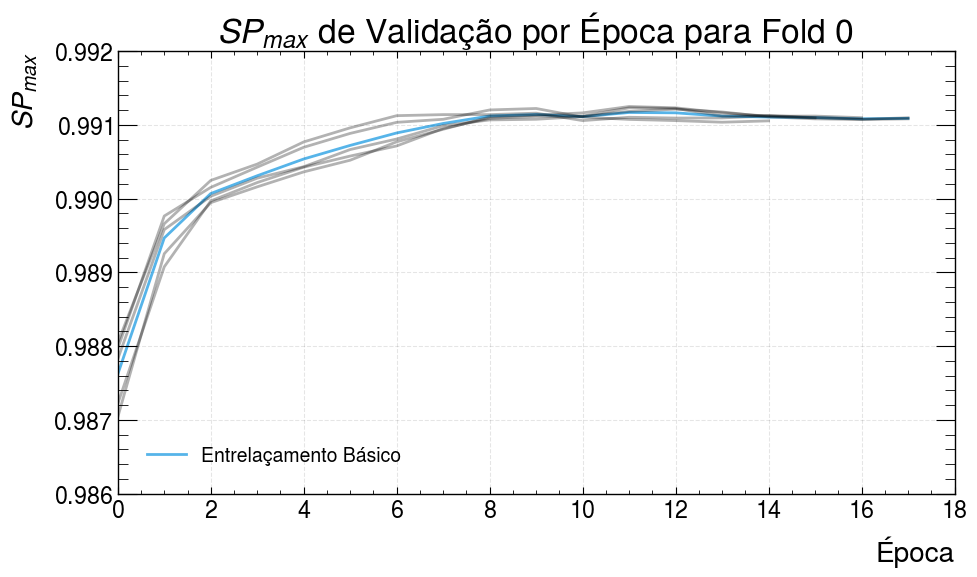

In [107]:
job_to_plot = jobs['basic_entangler']
metric_name = 'fit.max_sp_val'
metric_label = r'$SP_{max}$'
fold = 0
max_epochs = job_to_plot['results'][metric_name].list.len().max()
aux = job_to_plot['results'].filter(
    pl.col("fold") == fold
).select(
    pl.col(metric_name).list.to_struct(fields=lambda idx: str(idx), upper_bound=max_epochs)
).unnest(metric_name)
mean = aux.mean().to_numpy().flatten()

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.plot(
    np.arange(max_epochs),
    mean,
    color=job_to_plot['color'],
    label=job_to_plot['model_label'],
)
transposed_aux = aux.transpose()
for col in transposed_aux.columns:
    ax.plot(
        transposed_aux[col].to_numpy(),
        color='k',
        alpha=0.3
    )
ax.set_xlabel('Época')
ax.set_ylabel(metric_label)
ax.set_title(f'{metric_label} de Validação por Época para Fold {fold}')
ax.legend()
fig.tight_layout()

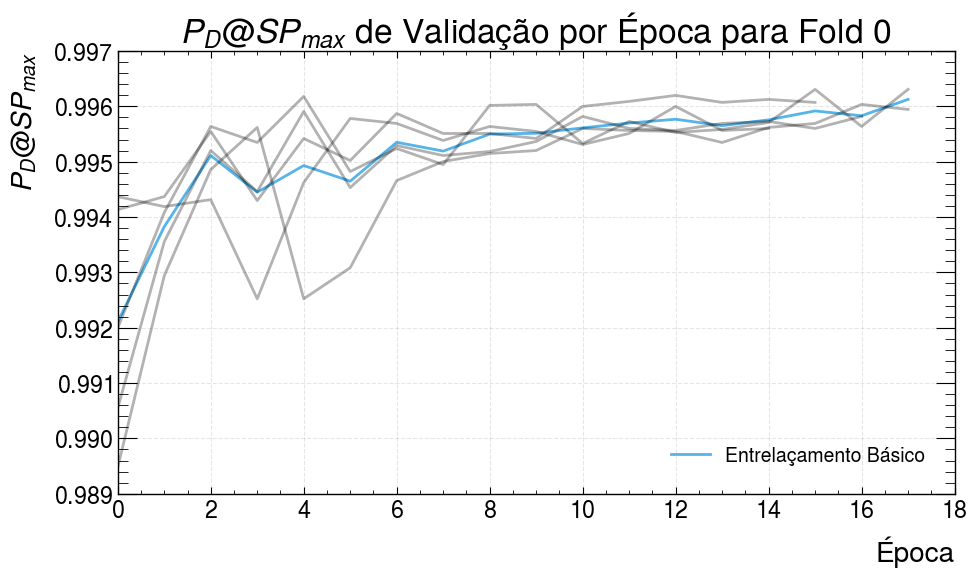

In [106]:
job_to_plot = jobs['basic_entangler']
metric_name = 'fit.max_sp_pd_val'
metric_label = r'$P_{D} @ SP_{max}$'
fold = 0
max_epochs = job_to_plot['results'][metric_name].list.len().max()
aux = job_to_plot['results'].filter(
    pl.col("fold") == fold
).select(
    pl.col(metric_name).list.to_struct(fields=lambda idx: str(idx), upper_bound=max_epochs)
).unnest(metric_name)
mean = aux.mean().to_numpy().flatten()

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.plot(
    np.arange(max_epochs),
    mean,
    color=job_to_plot['color'],
    label=job_to_plot['model_label'],
)
transposed_aux = aux.transpose()
for col in transposed_aux.columns:
    ax.plot(
        transposed_aux[col].to_numpy(),
        color='k',
        alpha=0.3
    )
ax.set_xlabel('Época')
ax.set_ylabel(metric_label)
ax.set_title(f'{metric_label} de Validação por Época para Fold {fold}')
ax.legend()
fig.tight_layout()

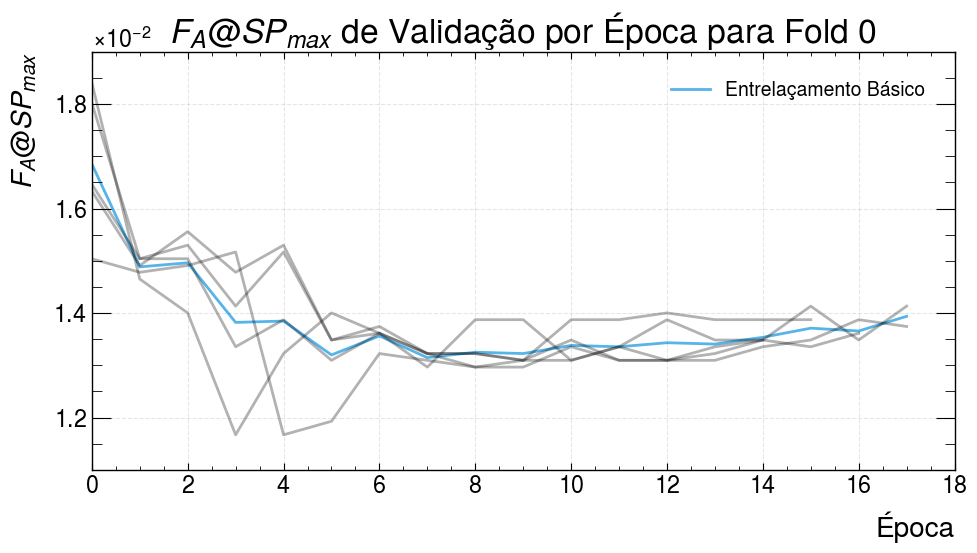

In [108]:
job_to_plot = jobs['basic_entangler']
metric_name = 'fit.max_sp_fa_val'
metric_label = r'$F_{A} @ SP_{max}$'
fold = 0
max_epochs = job_to_plot['results'][metric_name].list.len().max()
aux = job_to_plot['results'].filter(
    pl.col("fold") == fold
).select(
    pl.col(metric_name).list.to_struct(fields=lambda idx: str(idx), upper_bound=max_epochs)
).unnest(metric_name)
mean = aux.mean().to_numpy().flatten()

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.plot(
    np.arange(max_epochs),
    mean,
    color=job_to_plot['color'],
    label=job_to_plot['model_label'],
)
transposed_aux = aux.transpose()
for col in transposed_aux.columns:
    ax.plot(
        transposed_aux[col].to_numpy(),
        color='k',
        alpha=0.3
    )
ax.set_xlabel('Época')
ax.set_ylabel(metric_label)
ax.set_title(f'{metric_label} de Validação por Época para Fold {fold}')
ax.legend()
fig.tight_layout()